<a href="https://colab.research.google.com/github/thunerous/MH/blob/main/%D0%9B%D0%A0_12_%D0%9C%D0%9D_%D0%A1i%D0%B4%D0%BE%D1%80%D1%86%D0%B5%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
meowmeowmeowmeowmeow_gtsrb_german_traffic_sign_path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')

print('Data source import complete.')


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from tensorflow.keras.layers import (Input, Rescaling, RandomFlip, RandomRotation, RandomContrast,
                                     Conv2D, BatchNormalization, MaxPool2D,
                                     GlobalAveragePooling2D, Dense, Dropout)

from tensorflow.keras.regularizers import l2

In [ ]:
train_images_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_images_dir,
    target_size=(32, 32),
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_images_dir,
    target_size=(32, 32),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Кількість тренувальних зразків: {train_generator.samples}")
print(f"Кількість валідаційних зразків: {val_generator.samples}")
print(f"Кількість класів: {train_generator.num_classes}")

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Кількість тренувальних зразків: 31368
Кількість валідаційних зразків: 7841
Кількість класів: 43


In [ ]:
height, width, channels = 32, 32, 3
NUM_CATEGORIES = 43

model = Sequential([
    Input(shape=(height, width, channels))
])

In [ ]:
height, width, channels = 32,32,3
NUM_CATEGORIES=43
model = Sequential([
    Input(shape=(height, width, channels)),

    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomContrast(0.1),

    Conv2D(32, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPool2D(),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPool2D(),

    Conv2D(128, (3,3), padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPool2D(),

    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CATEGORIES, activation="softmax")
])

I0000 00:00:1776520849.228493      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776520849.234496      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import TopKCategoricalAccuracy

LOSS = CategoricalCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=LOSS,
    metrics=[
        "accuracy",
        TopKCategoricalAccuracy(k=3, name="top3")
    ]
)

cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=cb,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1776520860.048734     195 cuda_dnn.cc:529] Loaded cuDNN version 91002


491/491 ━━━━━━━━━━━━━━━━━━━━ 296s 583ms/step - accuracy: 0.1017 - loss: 3.6087 - top3: 0.2346 - val_accuracy: 0.0626 - val_loss: 3.7296 - val_top3: 0.1511 - learning_rate: 3.0000e-04
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 129s 263ms/step - accuracy: 0.2919 - loss: 2.5128 - top3: 0.5168 - val_accuracy: 0.3686 - val_loss: 2.2310 - val_top3: 0.6203 - learning_rate: 3.0000e-04
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - accuracy: 0.4836 - loss: 1.6952 - top3: 0.7267 - val_accuracy: 0.4227 - val_loss: 2.0120 - val_top3: 0.6442 - learning_rate: 3.0000e-04
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 70s 142ms/step - accuracy: 0.6421 - loss: 1.1566 - top3: 0.8595 - val_accuracy: 0.2947 - val_loss: 2.5997 - val_top3: 0.4711 - learning_rate: 3.0000e-04
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 73s 148ms/step - accuracy: 0.7481 - loss: 0.8066 - top3: 0.9316 - val_accuracy: 0.6617 - val_loss: 1.1595 - val_top3: 0.8743 - learning_rate: 3.0000e-04
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 83s 

In [ ]:
training_accuracy = history.history["accuracy"]
training_loss = history.history["loss"]
validation_accuracy = history.history["val_accuracy"]
validation_loss = history.history["val_loss"]

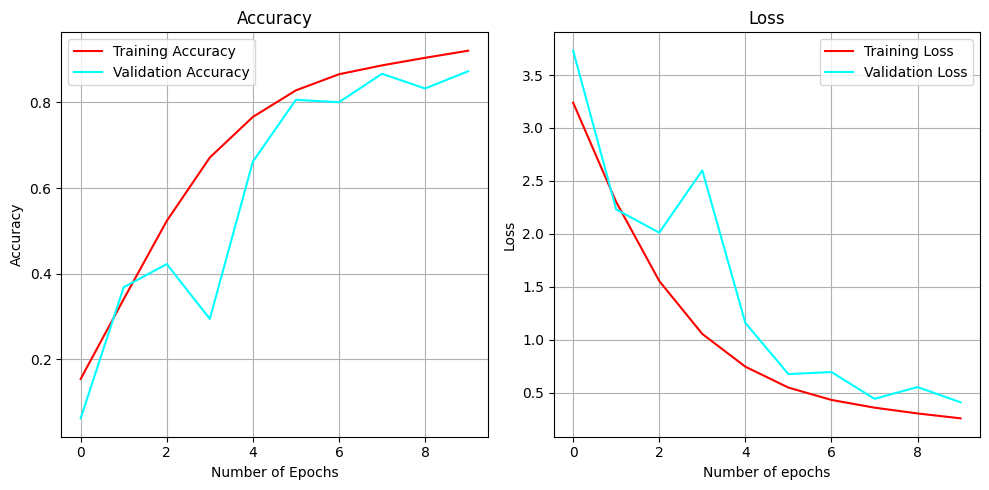

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(training_accuracy, color="red", label="Training Accuracy")
plt.plot(validation_accuracy, color="cyan", label="Validation Accuracy")
plt.legend()
plt.grid(True)
plt.title("Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(training_loss, color="red", label="Training Loss")
plt.plot(validation_loss, color="cyan", label="Validation Loss")
plt.grid(True)
plt.legend()
plt.title("Loss")
plt.xlabel("Number of epochs")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

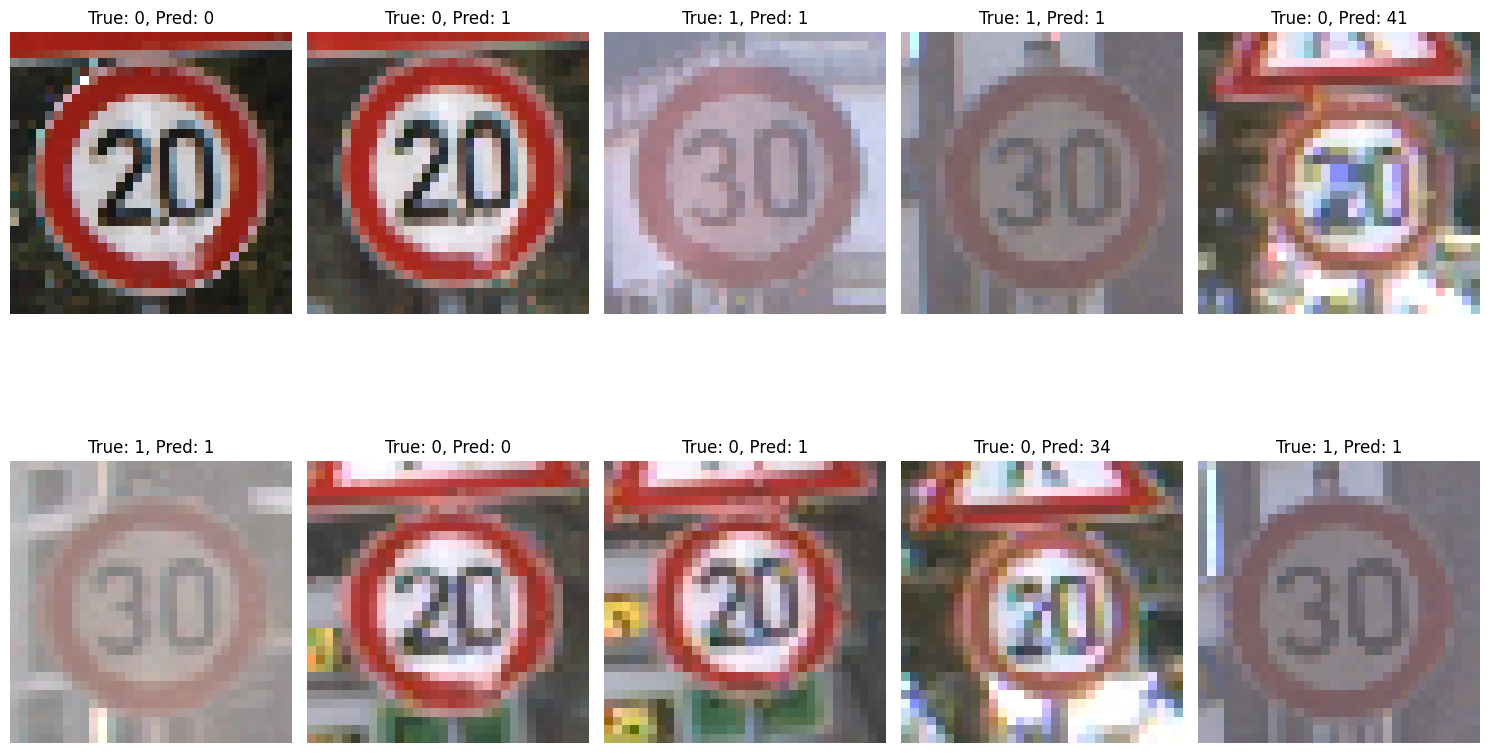

In [ ]:
x_batch, y_batch = next(val_generator)

y_pred = model.predict(x_batch, verbose=0)

random_indices = np.random.choice(len(x_batch), size=min(10, len(x_batch)), replace=False)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_batch[idx])
    plt.axis("off")

    true_class = np.argmax(y_batch[idx])
    predicted_class = np.argmax(y_pred[idx])

    plt.title(f"True: {true_class}, Pred: {predicted_class}")

plt.tight_layout()
plt.show()